In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

def load_dataset():
    df = pd.read_csv(DATA_URL, sep="\t", names=["label", "message"])
    return df

def preprocess_labels(df):
    df["label"] = df["label"].map({"ham":0, "spam":1})
    return df

def split_data(df, test_size=0.2, random_state=42):
    
    X = df["message"]
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test

def get_processed_data():
    
    df = load_dataset()
    df = preprocess_labels(df)

    X_train, X_test, y_train, y_test = split_data(df)

    return X_train, X_test, y_train, y_test

In [2]:
X_train, X_test, y_train, y_test = get_processed_data()

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [4]:
from sklearn.svm import SVC

svm_model = SVC(kernel="linear")

svm_model.fit(X_train_vec, y_train)

SVC(kernel='linear')

In [5]:
svm_pred = svm_model.predict(X_test_vec)

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Confusion Matrix:
[[965   1]
 [ 17 132]]


In [7]:
print("Accuracy:", accuracy_score(y_test, svm_pred))

Accuracy: 0.9838565022421525


In [8]:
print("Precision:", precision_score(y_test, svm_pred))

Precision: 0.9924812030075187


In [9]:
print("Recall:", recall_score(y_test, svm_pred))

Recall: 0.8859060402684564


In [10]:
print("F1 Score:", f1_score(y_test, svm_pred))

F1 Score: 0.9361702127659575


In [11]:
import time

In [12]:
start = time.time()

svm_model.fit(X_train_vec, y_train)

train_time = time.time() - start

print("Training Time:", train_time)

Training Time: 1.0398082733154297


In [13]:
start = time.time()

svm_pred = svm_model.predict(X_test_vec)

test_time = time.time() - start

print("Testing Time:", test_time)

Testing Time: 0.17695379257202148


In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.preprocessing import normalize

In [15]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [17]:
X = df['message']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [18]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    stop_words='english'
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [19]:
X_train = normalize(X_train)
X_test = normalize(X_test)

In [20]:
knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='cosine'
)

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=3, weights='distance')

In [21]:
y_pred = knn.predict(X_test)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9551569506726457
Precision: 0.8413793103448276
Recall: 0.8187919463087249
F1 Score: 0.8299319727891157


In [23]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[943  23]
 [ 27 122]]


In [24]:
import time

start_train = time.time()

knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='cosine'
)

knn.fit(X_train, y_train)

end_train = time.time()

train_time = end_train - start_train
print("Training Time (seconds):", train_time)

Training Time (seconds): 0.004378080368041992


In [25]:
start_test = time.time()

y_pred = knn.predict(X_test)

end_test = time.time()

test_time = end_test - start_test
print("Testing Time (seconds):", test_time)

Testing Time (seconds): 0.14430880546569824


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

def load_dataset():
    df = pd.read_csv(DATA_URL, sep="\t", names=["label", "message"])
    return df

def preprocess_labels(df):
    df["label"] = df["label"].map({"ham":0, "spam":1})
    return df

def split_data(df, test_size=0.2, random_state=42):
    
    X = df["message"]
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test

def get_processed_data():
    
    df = load_dataset()
    df = preprocess_labels(df)

    X_train, X_test, y_train, y_test = split_data(df)

    return X_train, X_test, y_train, y_test

In [28]:
X_train, X_test, y_train, y_test = get_processed_data()

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [30]:
X_train_dense = X_train_vec.toarray()
X_test_dense = X_test_vec.toarray()

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train_dense, y_train)

LinearDiscriminantAnalysis()

In [32]:
lda_pred = lda_model.predict(X_test_dense)

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [35]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, lda_pred))
print("Accuracy:", accuracy_score(y_test, lda_pred))
print("Precision:", precision_score(y_test, lda_pred))
print("Recall:", recall_score(y_test, lda_pred))
print("F1 Score:", f1_score(y_test, lda_pred))

Confusion Matrix:
[[964   2]
 [ 27 122]]
Accuracy: 0.9739910313901345
Precision: 0.9838709677419355
Recall: 0.8187919463087249
F1 Score: 0.8937728937728938


In [36]:
import time

start = time.time()

lda_model.fit(X_train_dense, y_train)

train_time = time.time() - start

print("Training Time:", train_time)

Training Time: 93.32155990600586


In [37]:
start = time.time()

lda_pred = lda_model.predict(X_test_dense)

test_time = time.time() - start

print("Testing Time:", test_time)

Testing Time: 0.031687021255493164


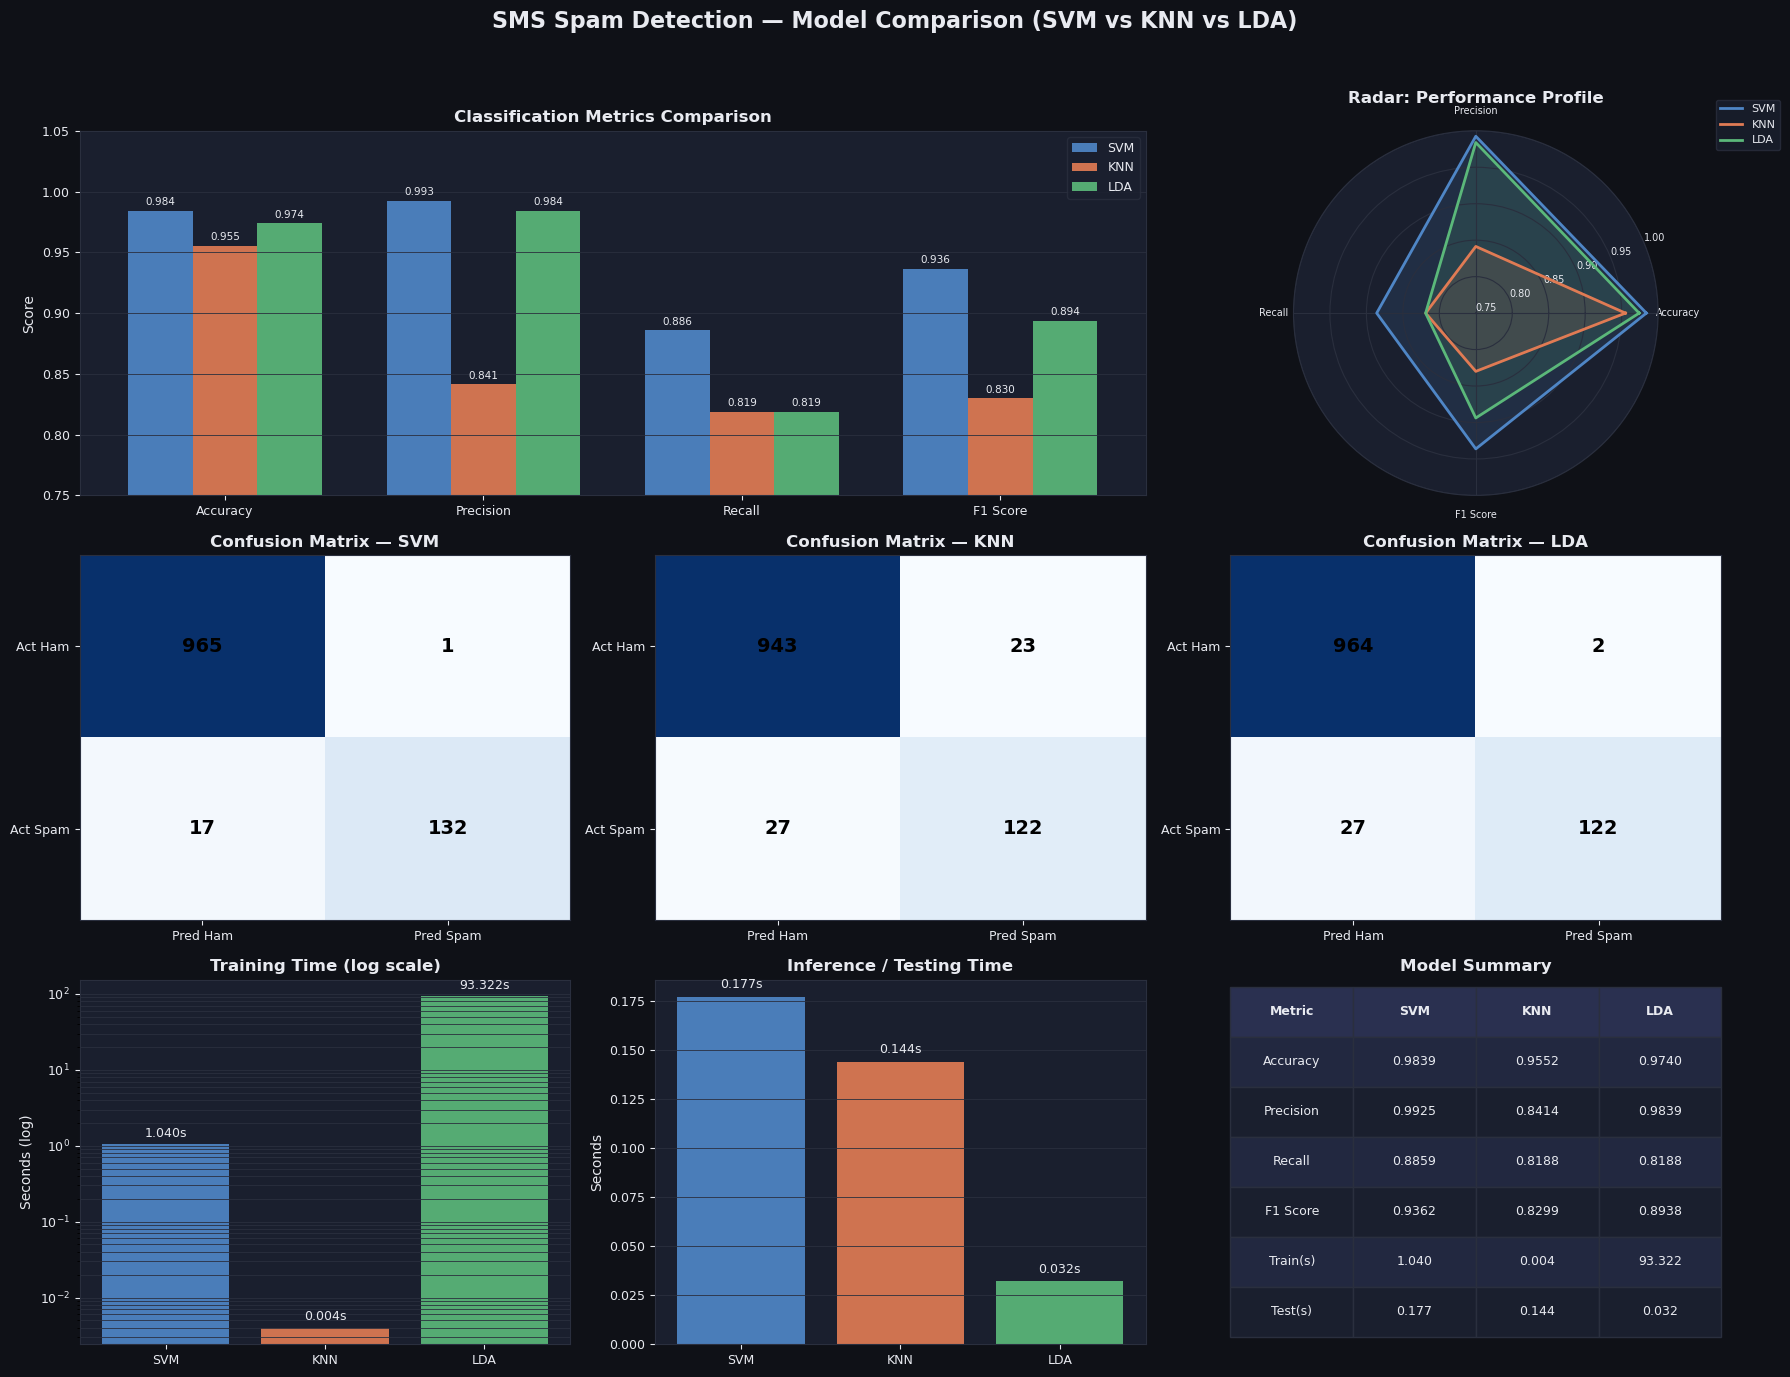

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data from notebook results ─────────────────────────────────────────────────
models = ['SVM', 'KNN', 'LDA']

metrics = {
    'Accuracy':  [0.9839, 0.9552, 0.9740],
    'Precision': [0.9925, 0.8414, 0.9839],
    'Recall':    [0.8859, 0.8188, 0.8188],
    'F1 Score':  [0.9362, 0.8299, 0.8938],
}

conf_matrices = {
    'SVM': np.array([[965,  1], [17, 132]]),
    'KNN': np.array([[943, 23], [27, 122]]),
    'LDA': np.array([[964,  2], [27, 122]]),
}

train_times = [1.040, 0.004, 93.322]
test_times  = [0.177, 0.144, 0.032]

# ── Palette ────────────────────────────────────────────────────────────────────
C = {'SVM': '#4f86c6', 'KNN': '#e07b54', 'LDA': '#5bb87a'}
colors = [C[m] for m in models]
BG   = '#0f1117'
CARD = '#1a1f2e'
TEXT = '#e8eaf0'
GRID = '#2a2f3e'

def style_ax(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.spines[:].set_color(GRID)
    ax.title.set_color(TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.grid(color=GRID, linewidth=0.6, axis='y')

fig = plt.figure(figsize=(18, 14), facecolor=BG)
fig.suptitle('SMS Spam Detection — Model Comparison (SVM vs KNN vs LDA)',
             fontsize=16, fontweight='bold', color=TEXT, y=0.98)

# ── 1. Grouped bar: all 4 metrics ─────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, (1, 2))
x = np.arange(len(metrics))
w = 0.25
for i, (m, c) in enumerate(zip(models, colors)):
    vals = [metrics[k][i] for k in metrics]
    bars = ax1.bar(x + (i - 1) * w, vals, w, label=m, color=c, edgecolor='none', alpha=0.92)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, color=TEXT)
ax1.set_title('Classification Metrics Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(list(metrics.keys()))
ax1.set_ylim(0.75, 1.05)
ax1.set_ylabel('Score')
ax1.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
style_ax(ax1)

# ── 2. Radar chart ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 3, polar=True)
ax2.set_facecolor(CARD)
metric_labels = list(metrics.keys())
angles = np.linspace(0, 2 * np.pi, len(metric_labels), endpoint=False).tolist()
angles += angles[:1]
for i, (m, c) in enumerate(zip(models, colors)):
    vals = [metrics[k][i] for k in metric_labels] + [metrics[metric_labels[0]][i]]
    ax2.plot(angles, vals, color=c, linewidth=2, label=m)
    ax2.fill(angles, vals, color=c, alpha=0.15)
ax2.set_thetagrids(np.degrees(angles[:-1]), metric_labels, color=TEXT, fontsize=9)
ax2.set_ylim(0.75, 1.0)
ax2.set_title('Radar: Performance Profile', color=TEXT, fontweight='bold', pad=20)
ax2.tick_params(colors=TEXT, labelsize=7)
ax2.spines['polar'].set_color(GRID)
for line in ax2.yaxis.get_gridlines(): line.set_color(GRID)
for line in ax2.xaxis.get_gridlines(): line.set_color(GRID)
ax2.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT, fontsize=8,
           loc='upper right', bbox_to_anchor=(1.35, 1.1))

# ── 3. Confusion matrices ──────────────────────────────────────────────────────
for col, m in enumerate(models):
    ax = fig.add_subplot(3, 3, 4 + col)
    cm = conf_matrices[m]
    ax.imshow(cm, cmap='Blues', aspect='auto')
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred Ham', 'Pred Spam'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Act Ham', 'Act Spam'])
    ax.set_title(f'Confusion Matrix — {m}', fontweight='bold')
    style_ax(ax)
    ax.grid(False)

# ── 4. Training time (log scale) ──────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
bars = ax7.bar(models, train_times, color=colors, edgecolor='none', alpha=0.92)
for bar, v in zip(bars, train_times):
    ax7.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
             f'{v:.3f}s', ha='center', va='bottom', fontsize=9, color=TEXT)
ax7.set_yscale('log')
ax7.set_title('Training Time (log scale)', fontweight='bold')
ax7.set_ylabel('Seconds (log)')
style_ax(ax7)
ax7.grid(color=GRID, linewidth=0.6, axis='y', which='both')

# ── 5. Testing time ────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
bars = ax8.bar(models, test_times, color=colors, edgecolor='none', alpha=0.92)
for bar, v in zip(bars, test_times):
    ax8.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{v:.3f}s', ha='center', va='bottom', fontsize=9, color=TEXT)
ax8.set_title('Inference / Testing Time', fontweight='bold')
ax8.set_ylabel('Seconds')
style_ax(ax8)

# ── 6. Summary scorecard ───────────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ax9.set_facecolor(CARD)
ax9.axis('off')
ax9.set_title('Model Summary', fontweight='bold', color=TEXT)
rows = [['Metric', 'SVM', 'KNN', 'LDA']]
for k, vals in metrics.items():
    rows.append([k] + [f'{v:.4f}' for v in vals])
rows.append(['Train(s)', '1.040', '0.004', '93.322'])
rows.append(['Test(s)',  '0.177', '0.144', '0.032'])
table = ax9.table(cellText=rows[1:], colLabels=rows[0],
                  cellLoc='center', loc='center', bbox=[0, 0.02, 1, 0.96])
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor(CARD if r % 2 == 0 else '#222840')
    cell.set_edgecolor(GRID)
    cell.set_text_props(color=TEXT)
    if r == 0:
        cell.set_facecolor('#2a3050')
        cell.set_text_props(color=TEXT, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()